<a href="https://colab.research.google.com/github/ahmed123234/zoomcamp-ML/blob/main/hair_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget 'https://github.com/SVizor42/ML_Zoomcamp/releases/download/straight-curly-data/data.zip'

--2025-11-23 17:40:44--  https://github.com/SVizor42/ML_Zoomcamp/releases/download/straight-curly-data/data.zip
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/405934815/e712cf72-f851-44e0-9c05-e711624af985?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-11-23T18%3A32%3A54Z&rscd=attachment%3B+filename%3Ddata.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-11-23T17%3A32%3A45Z&ske=2025-11-23T18%3A32%3A54Z&sks=b&skv=2018-11-09&sig=SLb3Lz2DoYcpz7vfozV0MSH5KxSGmodqT1PZtVzzS%2F4%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2MzkyMTQ0NCwibmJmIjoxNzYzOTE5NjQ0LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5i

In [ ]:
!unzip data.zip

Archive:  data.zip
   creating: data/
   creating: data/test/
   creating: data/test/curly/
  inflating: data/test/curly/03312ac556a7d003f7570657f80392c34.jpg  
  inflating: data/test/curly/106dfcf4abe76990b585b2fc2e3c9f884.jpg  
  inflating: data/test/curly/1a9dbe23a0d95f1c292625960e4509184.jpg  
  inflating: data/test/curly/341ea26e6677b655f8447af56073204a4.jpg  
  inflating: data/test/curly/61aPFVrm42L._SL1352_.jpg  
  inflating: data/test/curly/6d8acb0fe980774ea4e5631198587f45.png  
  inflating: data/test/curly/7f5649a0c33a2b334f23221a52c16b9b.jpg  
  inflating: data/test/curly/90146673.jpg  
  inflating: data/test/curly/9b3608e01d78fbabc9fb0719323d507f4.jpg  
  inflating: data/test/curly/b171c99161f3cffc12d4b74488ef2fc6.jpg  
  inflating: data/test/curly/blogger_one.jpg  
  inflating: data/test/curly/c03ca1590aa4df74e922ad8257305a2b.jpg  
  inflating: data/test/curly/c1b89bb4f86a3478ec20ce1f63f003c1.jpg  
  inflating: data/test/curly/c5.jpg  
  inflating: data/test/curly/C86_76156

In [ ]:
import numpy as np
import torch

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
import os
from torch.utils.data import Dataset
from PIL import Image
# create the dataset
class HairDataset(Dataset):
    def __init__(self, data_dir, transform=None):
      # self.data = ImageFolder(data_dir, transform=transform)
        self.data_dir = data_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.classes = sorted(os.listdir(data_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        for label_name in self.classes:
            label_dir = os.path.join(data_dir, label_name)
            for img_name in os.listdir(label_dir):
                self.image_paths.append(os.path.join(label_dir, img_name))
                self.labels.append(self.class_to_idx[label_name])


    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
import torch.nn as nn
import torchvision.models as models

class HairClassifierMobileNet(nn.Module):
    def __init__(self, num_classes=1):
        super(HairClassifierMobileNet, self).__init__()

        # create the model
        self.model = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=(3, 3)),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 2)),
            # nn.Conv2d(32, 64, kernel_size=(3, 3)),
            # nn.ReLU(),
            # nn.MaxPool2d(kernel_size=(2, 2)),
            nn.Flatten(),
            nn.Linear(32 * 99 * 99, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

        # Add the Convonutional layer
        # nn.Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False, activation='relu')

        # Add custom layers
        # self.global_avg_pooling = nn.AdaptiveAvgPool2d((2, 2))

        # Turn the multi-dimensional result into vectors using flatten or view
        # self.flatten = nn.Flatten()

        # Next, add a nn.Linear layer with 64 neurons and 'relu' activation
        # self.linear_layer = nn.Linear(in_features=64, out_features=64)
        # self.output_layer = nn.Linear(in_features=64, out_features=num_classes)

    def forward(self, x):

        return self.model(x)

In [ ]:
import torch
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = HairClassifierMobileNet()
model.to(device)

optimizer = optim.SGD(model.parameters(), lr=0.002, momentum=0.8)
criterion = nn.BCEWithLogitsLoss()

In [ ]:
# Option 1: Using torchsummary (install with: pip install torchsummary)
from torchsummary import summary
summary(model, input_size=(3, 200, 200))



----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 198, 198]             896
              ReLU-2         [-1, 32, 198, 198]               0
         MaxPool2d-3           [-1, 32, 99, 99]               0
           Flatten-4               [-1, 313632]               0
            Linear-5                   [-1, 64]      20,072,512
              ReLU-6                   [-1, 64]               0
            Linear-7                    [-1, 1]              65
Total params: 20,073,473
Trainable params: 20,073,473
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.46
Forward/backward pass size (MB): 23.93
Params size (MB): 76.57
Estimated Total Size (MB): 100.96
----------------------------------------------------------------


In [ ]:
# Option 2: Manual counting
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 20073473


In [ ]:
# preprocessing
from torchvision import transforms

input_size = 200

# ImageNet normalization values
mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]

# Simple transforms - just resize and normalize
train_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [ ]:
# create data loaders
from torch.utils.data import DataLoader

train_dataset = HairDataset(
    data_dir='./data/train',
    transform=train_transforms
)

test_dataset = HairDataset(
    data_dir='./data/test',
    transform=test_transforms
)

train_loader = DataLoader(train_dataset, batch_size=20, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=20, shuffle=False)

In [ ]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([20, 3, 200, 200])
torch.Size([20])


In [ ]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([20, 3, 200, 200])
torch.Size([20])


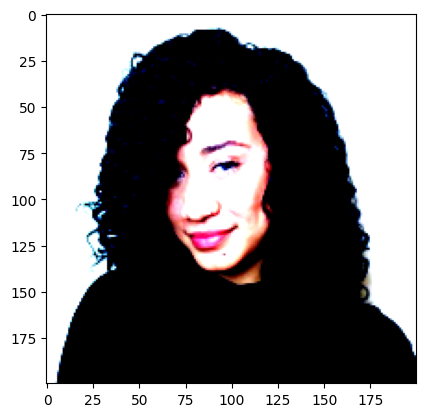

In [ ]:
# plot the first image
import matplotlib.pyplot as plt
plt.imshow(images[1].permute(1, 2, 0))

In [ ]:
num_epochs = 10
history = {'acc': [], 'loss': [], 'val_acc': [], 'val_loss': []}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        labels = labels.float().unsqueeze(1) # Ensure labels are float and have shape (batch_size, 1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        # For binary classification with BCEWithLogitsLoss, apply sigmoid to outputs before thresholding for accuracy
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct_train / total_train
    history['loss'].append(epoch_loss)
    history['acc'].append(epoch_acc)

    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            labels = labels.float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_epoch_loss = val_running_loss / len(test_dataset)
    val_epoch_acc = correct_val / total_val
    history['val_loss'].append(val_epoch_loss)
    history['val_acc'].append(val_epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}, "
          f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}")

Epoch 1/10, Loss: 0.6693, Acc: 0.6230, Val Loss: 0.6084, Val Acc: 0.6070
Epoch 2/10, Loss: 0.5662, Acc: 0.6954, Val Loss: 0.5863, Val Acc: 0.6617
Epoch 3/10, Loss: 0.5215, Acc: 0.7453, Val Loss: 0.7471, Val Acc: 0.5970
Epoch 4/10, Loss: 0.6023, Acc: 0.6941, Val Loss: 0.6007, Val Acc: 0.6965
Epoch 5/10, Loss: 0.5145, Acc: 0.7566, Val Loss: 0.6607, Val Acc: 0.6070
Epoch 6/10, Loss: 0.4995, Acc: 0.7428, Val Loss: 0.6510, Val Acc: 0.6766
Epoch 7/10, Loss: 0.4447, Acc: 0.7928, Val Loss: 0.5881, Val Acc: 0.6766
Epoch 8/10, Loss: 0.3878, Acc: 0.8277, Val Loss: 0.6686, Val Acc: 0.6567
Epoch 9/10, Loss: 0.3114, Acc: 0.8564, Val Loss: 0.8851, Val Acc: 0.6766
Epoch 10/10, Loss: 0.2751, Acc: 0.8714, Val Loss: 0.6072, Val Acc: 0.7065


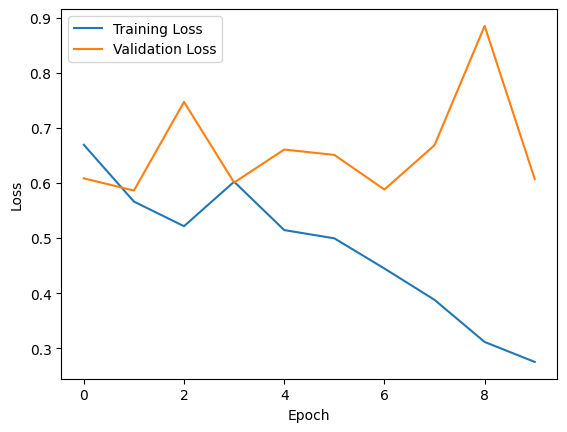

In [ ]:
# print history
import matplotlib.pyplot as plt
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# find the median of training accuracy for all the epochs for this model
import numpy as np
np.median(history['acc'])

np.float64(0.7509363295880149)

In [ ]:
# find the standard deviation of training loss for all the epochs for this model
np.std(history['loss'])



np.float64(0.1190144256844084)

In [ ]:
# preprocessing

train_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
    transforms.RandomRotation(50),
    transforms.RandomResizedCrop(200, scale=(0.9, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
])

# test_transforms = transforms.Compose([
#     transforms.Resize((input_size, input_size)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=mean, std=std)
# ])


train_dataset = HairDataset(
    data_dir='./data/train',
    transform=train_transforms
)

# test_dataset = HairDataset(
#     data_dir='./data/test',
#     transform=test_transforms
# )

train_loader = DataLoader(train_dataset, batch_size=20, shuffle=True)
# val_loader = DataLoader(test_dataset, batch_size=20, shuffle=False)

In [ ]:
num_epochs = 10
history = {'acc': [], 'loss': [], 'val_acc': [], 'val_loss': []}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        labels = labels.float().unsqueeze(1) # Ensure labels are float and have shape (batch_size, 1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        # For binary classification with BCEWithLogitsLoss, apply sigmoid to outputs before thresholding for accuracy
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct_train / total_train
    history['loss'].append(epoch_loss)
    history['acc'].append(epoch_acc)

    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            labels = labels.float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_epoch_loss = val_running_loss / len(test_dataset)
    val_epoch_acc = correct_val / total_val
    history['val_loss'].append(val_epoch_loss)
    history['val_acc'].append(val_epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}, "
          f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}")

Epoch 1/10, Loss: 0.6316, Acc: 0.6692, Val Loss: 0.5693, Val Acc: 0.6617
Epoch 2/10, Loss: 0.5854, Acc: 0.6792, Val Loss: 0.5873, Val Acc: 0.6866
Epoch 3/10, Loss: 0.5577, Acc: 0.6879, Val Loss: 0.5617, Val Acc: 0.7164
Epoch 4/10, Loss: 0.5362, Acc: 0.7091, Val Loss: 0.5561, Val Acc: 0.7015
Epoch 5/10, Loss: 0.5509, Acc: 0.7353, Val Loss: 0.5687, Val Acc: 0.7065
Epoch 6/10, Loss: 0.5074, Acc: 0.7291, Val Loss: 0.5517, Val Acc: 0.6866
Epoch 7/10, Loss: 0.4820, Acc: 0.7640, Val Loss: 0.5547, Val Acc: 0.7463
Epoch 8/10, Loss: 0.4871, Acc: 0.7678, Val Loss: 0.5437, Val Acc: 0.7313
Epoch 9/10, Loss: 0.4698, Acc: 0.7665, Val Loss: 0.5744, Val Acc: 0.7114
Epoch 10/10, Loss: 0.4942, Acc: 0.7366, Val Loss: 0.5151, Val Acc: 0.7363


In [ ]:
# find the mean of test loss for all the epochs for the model trained with augmentations
np.mean(history['val_loss'])

np.float64(0.5582827738861539)

In [ ]:
# find the average of test accuracy for the last 5 epochs (from 6 to 10) for the model trained with augmentations
np.mean(history['val_acc'][6:])

np.float64(0.7313432835820894)

In [ ]:
# Training loop
num_epochs = 10

for epoch in range(num_epochs):
    # Training phase
    model.train()  # Set the model to training mode
    running_loss = 0.0
    correct = 0
    total = 0

    # Iterate over the training data
    for inputs, labels in train_loader:
        # Move data to the specified device (GPU or CPU)
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients to prevent accumulation
        optimizer.zero_grad()
        # Forward pass
        outputs = model(inputs)
        # Calculate the loss
        loss = criterion(outputs, labels)
        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Accumulate training loss
        running_loss += loss.item()
        # Get predictions
        _, predicted = torch.max(outputs.data, 1)
        # Update total and correct predictions
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Calculate average training loss and accuracy
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # # Validation phase
    model.eval()  # Set the model to evaluation mode
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    # Disable gradient calculation for validation
    with torch.no_grad():
        # Iterate over the validation data
        for inputs, labels in val_loader:
            # Move data to the specified device (GPU or CPU)
            inputs, labels = inputs.to(device), labels.to(device)
            # Forward pass
            outputs = model(inputs)
            # Calculate the loss
            loss = criterion(outputs, labels)

            # Accumulate validation loss
            val_loss += loss.item()
            # Get predictions
            _, predicted = torch.max(outputs.data, 1)
            # Update total and correct predictions
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # Calculate average validation loss and accuracy
    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    # Print epoch results
    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
    print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

Epoch 1/10
  Train Loss: 0.6626, Train Acc: 0.5818
Epoch 2/10
  Train Loss: 0.6153, Train Acc: 0.6567
Epoch 3/10
  Train Loss: 0.6011, Train Acc: 0.6592
Epoch 4/10
  Train Loss: 0.5874, Train Acc: 0.6642
Epoch 5/10
  Train Loss: 0.5967, Train Acc: 0.6642
Epoch 6/10
  Train Loss: 0.5862, Train Acc: 0.6729
Epoch 7/10
  Train Loss: 0.5769, Train Acc: 0.6692
Epoch 8/10
  Train Loss: 0.5737, Train Acc: 0.6767
Epoch 9/10
  Train Loss: 0.5470, Train Acc: 0.7029
Epoch 10/10
  Train Loss: 0.5171, Train Acc: 0.7228
